# Multi-Class Prediction of Obesity Risk
## Four-Model Kaggle Classification Study

## Doug Perez

### School of Engineering & Technology, National University
### DDS 8555 -- Predictive Analytics
### Dr. Javier Leon
### August 14, 2026

**Course project:**  Predictive Analytics  
**Competition:**  Kaggle Playground Series S4E2  
**Target:**  `NObeyesdad` (seven obesity-risk classes)  
**Evaluation metric:**  Classification accuracy

This notebook develops and interprets four required classifiers:

1. Multinomial logistic regression
2. Regularized linear discriminant analysis (LDA)
3. Gaussian naïve Bayes
4. Radial-basis-function support vector machine (RBF SVM)

All preprocessing is learned inside each training pipeline to prevent data leakage.  Model selection uses a single stratified 80/20 development split with a fixed seed.  The final version of each selected pipeline is refitted on all 20,758 labeled observations and used to create a separate Kaggle submission file.

## Scholarly context

Obesity is a multifactorial health condition associated with anthropometric measurements, eating patterns, physical activity, family history, demographic characteristics, and other lifestyle factors.  Estimating obesity level can therefore be approached as a supervised multiclass classification problem in which a model uses several predictors to assign each individual to one of seven weight-status categories:  insufficient weight, normal weight, overweight level I, overweight level II, obesity type I, obesity type II, or obesity type III.

### Dataset provenance and prior work

The Kaggle competition data were generated by a deep-learning model trained on the Obesity or Cardiovascular Disease Risk dataset documented by Palechor and de la Hoz Manotas (2019).  The original dataset represented individuals from Colombia, Peru, and Mexico and included variables describing age, gender, height, weight, family history of overweight, dietary habits, water and alcohol consumption, smoking, calorie monitoring, physical activity, technology use, and transportation choices.  These variables were selected to represent both anthropometric characteristics and behaviors that may be associated with obesity.

Palechor and de la Hoz Manotas (2019) reported that the original dataset contained 2,111 observations and 17 attributes.  Approximately 23% of the records were collected directly through a web-based survey, while 77% were generated synthetically using the Synthetic Minority Over-sampling Technique to address class imbalance.  The obesity categories were established primarily from body mass index, calculated from height and weight, and interpreted using recognized weight-status thresholds.  Consequently, height and weight are expected to be especially influential predictors because they contributed directly to the original labeling process.

The Kaggle competition introduces an additional synthetic-data layer because its training and test observations were produced by a deep-learning model fitted to the original obesity dataset.  This design provides a controlled setting for comparing classification algorithms, but it also limits external validity.  Synthetic observations may reproduce the statistical patterns in their source data without fully representing measurement error, population diversity, temporal changes, or other complexities found in directly observed health data.  Accordingly, the models developed in this assignment should be interpreted as competition classifiers rather than clinically validated diagnostic tools.

### Theoretical considerations

The four required classifiers use different theoretical assumptions and decision rules.  Multinomial logistic regression models the log-odds of each obesity category relative to a reference category as a linear function of the predictors.  Its coefficients can help explain how changes in individual variables affect the estimated probability of class membership.  However, the model assumes that continuous predictors relate linearly to the class log-odds.  It may therefore perform less effectively when the boundaries separating obesity categories are nonlinear.  Independent observations, limited harmful multicollinearity, absence of complete separation, and numerical convergence are also important considerations.

Linear discriminant analysis applies Bayes’ rule under the assumptions that the continuous predictors follow approximately multivariate normal distributions within each class and that all classes share a common covariance matrix.  These assumptions produce linear decision boundaries.  Because this dataset contains continuous, binary, ordinal, and nominal predictors, exact multivariate normality is unlikely.  Regularization can improve stability when predictors are correlated or covariance estimates are difficult to estimate, but the model’s results must still be interpreted in light of its distributional assumptions.

Gaussian naïve Bayes also applies Bayes’ rule, but it makes the stronger assumption that predictors are conditionally independent within each obesity category.  It additionally models each continuous predictor using a class-specific Gaussian distribution.  Conditional independence is unlikely to hold exactly because variables such as height, weight, age, eating habits, and physical activity can remain related within the same obesity category.  Violations may cause the model to count related information more than once or produce poorly calibrated class probabilities.  Within-class correlations, skewness, and class-specific errors are therefore important diagnostic evidence.

The support vector machine follows a different strategy.  It searches for a decision boundary that maximizes the margin between classes.  Cortes and Vapnik (1995) demonstrated that observations can be mapped into a higher-dimensional feature space in which a separating surface is constructed.  An SVM using a radial basis function kernel can produce nonlinear boundaries in the original predictor space without explicitly calculating every transformed feature.  The parameter \(C\) controls the tradeoff between maximizing the margin and penalizing classification errors, while \(\gamma\) controls the locality and flexibility of the radial kernel.  Because SVM decisions depend on distances between observations, continuous predictors must be standardized and the model’s hyperparameters should be selected through cross-validation.

### Recent applications

Recent obesity-prediction research increasingly uses machine-learning methods to capture nonlinear and interactive relationships among anthropometric, behavioral, demographic, and clinical characteristics.  Helforoush and Sayyad (2024) examined several supervised-learning approaches to seven-class obesity prediction, including logistic regression, SVM, ensemble methods, and artificial neural networks.  Their proposed hybrid artificial neural network and particle-swarm optimization model achieved 91.79% accuracy, outperforming the traditional comparison models examined in their study.  The authors also used feature-attribution methods to investigate how individual variables contributed to the predictions.

This recent work illustrates the potential value of flexible nonlinear methods for individualized risk classification and preventive health decision support.  However, it also demonstrates that accuracy should not be considered in isolation.  A multiclass model may achieve strong overall accuracy while performing poorly for particular obesity categories, especially adjacent categories whose anthropometric and behavioral characteristics overlap.  The present analysis therefore supplements accuracy with confusion matrices, balanced accuracy, macro-averaged \(F_1\), and class-specific precision and recall.

### Relevance to the present analysis

The three scholarly sources chosen address complementary elements of the assignment.  Palechor and de la Hoz Manotas (2019) establish the provenance, variables, labeling process, and intended classification use of the underlying dataset.  Cortes and Vapnik (1995) provide the theoretical foundation for maximum-margin classification and nonlinear kernel-based decision boundaries.  Helforoush and Sayyad (2024) provide a recent application of machine learning to multiclass obesity prediction and demonstrate the potential benefits of nonlinear models and model-interpretation techniques.

Comparing multinomial logistic regression, LDA, Gaussian naïve Bayes, and an RBF SVM is therefore more than a comparison of four accuracy values.  The analysis evaluates how linearity, distributional assumptions, conditional independence, regularization, feature scaling, and nonlinear decision boundaries affect classification within the same problem.  Differences in validation and Kaggle performance can consequently be interpreted in relation to the theoretical structure of each model and the empirical characteristics of the data.  Nevertheless, the results are predictive rather than causal, and the substantially synthetic origin of the data limits direct generalization to clinical or public-health populations.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import itertools, json, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 8555
TARGET = "NObeyesdad"
ID = "id"
CLASS_ORDER = [
    "Insufficient_Weight", "Normal_Weight", "Overweight_Level_I",
    "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II",
    "Obesity_Type_III"
]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

## 2. Load and verify the Kaggle files

In [2]:
# If running on Kaggle, replace DATA_DIR with the competition input directory.
DATA_DIR = Path("upload")
if not DATA_DIR.exists():
    DATA_DIR = Path("/kaggle/input/playground-series-s4e2")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("Training shape:", train.shape)
print("Test shape:", test.shape)
print("Submission template shape:", sample_submission.shape)
display(train.head())

assert train.shape == (20758, 18)
assert test.shape == (13840, 17)
assert sample_submission.columns.tolist() == [ID, TARGET]
assert train[ID].is_unique and test[ID].is_unique

Training shape: (20758, 18)
Test shape: (13840, 17)
Submission template shape: (13840, 2)


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


## 3. Exploratory analysis

In [3]:
print("Total missing values in training data:", int(train.isna().sum().sum()))
print("Total missing values in test data:", int(test.isna().sum().sum()))

class_summary = train[TARGET].value_counts().reindex(CLASS_ORDER).to_frame("Count")
class_summary["Percent"] = 100 * class_summary["Count"] / len(train)
display(class_summary.round(2))
display(train.describe().T.round(3))

Total missing values in training data: 0
Total missing values in test data: 0


,Count,Percent
NObeyesdad,,
Insufficient_Weight,2523,12.15
Normal_Weight,3082,14.85
Overweight_Level_I,2427,11.69
Overweight_Level_II,2522,12.15
Obesity_Type_I,2910,14.02
Obesity_Type_II,3248,15.65
Obesity_Type_III,4046,19.49


,count,mean,std,min,25%,50%,75%,max
id,20758.0,10378.500,5992.463,0.00,5189.250,10378.500,15567.750,20757.000
Age,20758.0,23.842,5.688,14.00,20.000,22.815,26.000,61.000
Height,20758.0,1.700,0.087,1.45,1.632,1.700,1.763,1.976
Weight,20758.0,87.888,26.379,39.00,66.000,84.065,111.601,165.057
FCVC,20758.0,2.446,0.533,1.00,2.000,2.394,3.000,3.000
NCP,20758.0,2.761,0.705,1.00,3.000,3.000,3.000,4.000
CH2O,20758.0,2.029,0.608,1.00,1.792,2.000,2.550,3.000
FAF,20758.0,0.982,0.838,0.00,0.008,1.000,1.587,3.000
TUE,20758.0,0.617,0.602,0.00,0.000,0.574,1.000,2.000


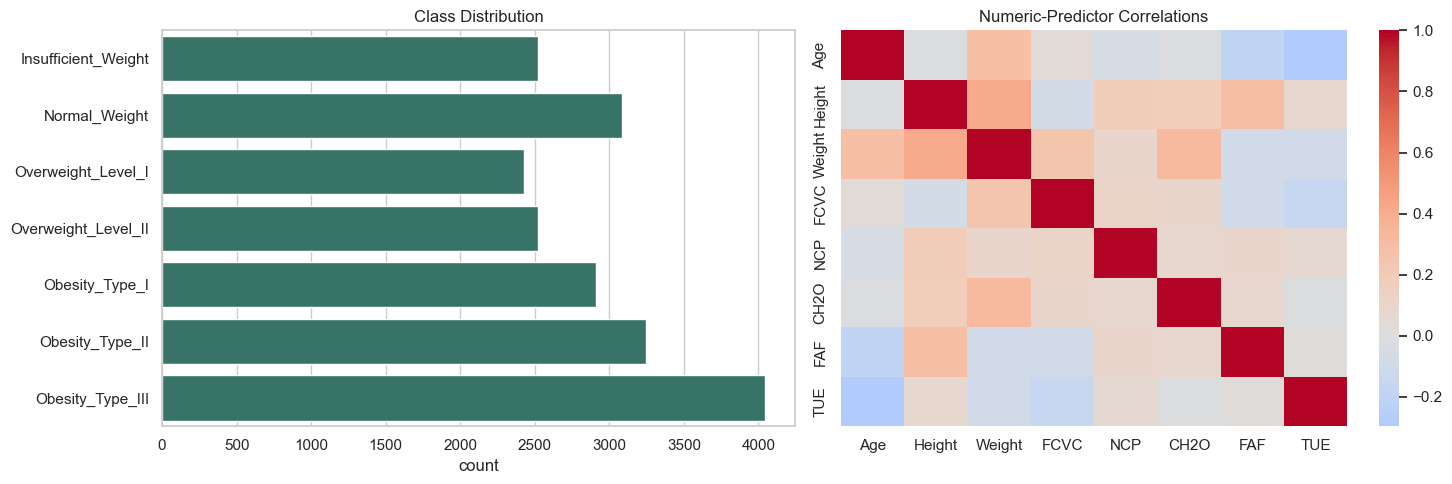

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=train, y=TARGET, order=CLASS_ORDER, ax=axes[0], color="#2E7D6E")
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("")

numeric_raw = train.select_dtypes(include=np.number).drop(columns=ID)
sns.heatmap(numeric_raw.corr(), cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Numeric-Predictor Correlations")
plt.tight_layout()
plt.show()

### Exploratory findings

The preliminary examination identified no missing values in either the training predictors or the target variable.  This result simplifies preprocessing because the analysis does not require deletion, statistical imputation, or the creation of missingness indicators.  It also ensures that every training observation can contribute to model estimation and validation.  Nevertheless, completeness should not be interpreted as proof of data quality.  The largely synthetic origin of the competition data means that repeated patterns, unusual distributions, implausible combinations, or differences between the training and test sets remain possible even when every field contains a value.  The exploratory analysis therefore also examines class frequencies, predictor distributions, categorical levels, correlations, and potential differences between the training and test data.

The seven outcome categories are not represented equally.  `Obesity_Type_III` is the largest class with 4,046 observations, while `Overweight_Level_I` is the smallest with 2,427 observations.  The largest class is therefore approximately 1.67 times the size of the smallest class.  This distribution indicates moderate class imbalance, but it is not sufficiently extreme to prevent the models from learning each category.  Every class contains several thousand observations, providing a substantial number of examples for model development and validation.

Although the imbalance is not severe, it can still affect the interpretation of model performance.  A classifier can improve its overall accuracy by favoring categories that appear more frequently, even if its predictions for smaller classes are comparatively weak.  Ordinary accuracy remains the primary evaluation measure because it aligns directly with the Kaggle competition metric and represents the proportion of all observations classified correctly.  However, accuracy alone cannot show whether errors are distributed equitably across the seven classes.

Balanced accuracy and macro-averaged \(F_1\) are therefore retained as complementary measures.  Balanced accuracy assigns equal importance to the recall achieved within each class, preventing the largest categories from dominating the evaluation.  Macro-\(F_1\) calculates the \(F_1\) score separately for every category and then gives each category equal weight.  It therefore considers both precision and recall without weighting the results according to class frequency.  When accuracy, balanced accuracy, and macro-\(F_1\) are similar, the model is performing relatively consistently across categories.  A substantial difference would suggest that a favorable overall accuracy is concealing weaker performance for one or more less-common classes.

The target categories also possess a meaningful conceptual order.  They progress from insufficient weight through normal weight and two overweight levels to three obesity types.  The Kaggle competition nevertheless treats these categories as nominal outcomes:  each incorrect prediction receives the same penalty regardless of how far the predicted category is from the actual category.  For example, predicting `Overweight_Level_II` for an observation whose actual class is `Obesity_Type_I` is penalized in the same manner as predicting `Insufficient_Weight`, even though the first error is between adjacent categories and is substantively much closer.

This distinction is important when interpreting the confusion matrices.  Because the original categories are closely related to body-mass-index intervals, observations near a category boundary may have very similar height and weight values even though they receive different labels.  Adjacent categories may also share similar eating, activity, and demographic characteristics.  The most plausible errors are therefore expected between neighboring categories, such as `Normal_Weight` and `Overweight_Level_I` or `Obesity_Type_I` and `Obesity_Type_II`, rather than between the most distant categories.

Accordingly, the analysis evaluates not only how many predictions are incorrect but also where those errors occur.  A model whose mistakes are concentrated among adjacent categories may be more substantively reasonable than a model that produces the same accuracy while confusing extreme categories.  This additional interpretation does not alter the official Kaggle score, but it provides a more informative assessment of the classifiers’ behavior and their potential usefulness beyond the competition.

Finally, the exploratory findings help establish expectations for the four required models.  The presence of mixed numeric and categorical predictors requires model-specific preprocessing.  Differences in scale are particularly important for the SVM because its decision function depends on distances in the transformed predictor space.  Correlation among anthropometric and behavioral variables may affect multinomial logistic regression, LDA, and Gaussian naïve Bayes in different ways.  Nonlinear relationships and overlapping class boundaries may favor the radial-kernel SVM, while violations of conditional independence may weaken naïve Bayes.  These expectations are investigated through the subsequent assumption diagnostics, cross-validation results, confusion matrices, and class-specific performance measures.

## 4. Feature engineering and leakage-safe preprocessing

In [5]:
def engineer_features(frame):
    result = frame.drop(columns=[ID], errors="ignore").copy()
    result["BMI"] = result["Weight"] / result["Height"].pow(2)
    result["Age_sq"] = result["Age"].pow(2)
    return result

X = engineer_features(train.drop(columns=TARGET))
y = train[TARGET]
X_kaggle = engineer_features(test)

categorical_features = X.select_dtypes(include="object").columns.tolist()
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
], sparse_threshold=0)

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Training observations:", len(X_train))
print("Validation observations:", len(X_valid))

Numeric features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI', 'Age_sq']
Categorical features: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Training observations: 16606
Validation observations: 4152


## 5. Assumption investigation

### Independence and representativeness

The modeling pipelines assume that rows are independently sampled and that the development, validation, and competition test observations arise from sufficiently comparable distributions.  Independence cannot be established conclusively from the available data, but record identifiers and duplicate patterns can be examined for evidence that observations may be related or repeated.  IDs are excluded from all models because they identify records rather than substantive characteristics and could introduce spurious relationships that would not generalize beyond the competition data.

The competition states that the training and test observations were generated by a deep-learning model trained on the original obesity dataset.  Synthetic generation may create repeated, highly regular, or simplified patterns that make observations easier to classify than independently collected clinical records.  Consequently, strong validation and Kaggle performance demonstrate predictive effectiveness within the competition setting but should not automatically be interpreted as evidence of clinical validity or population-level generalizability.

### Multinomial logistic regression

Multinomial logistic regression assumes independent observations, correct specification of the class log-odds, limited harmful multicollinearity, and no complete or quasi-complete separation.  The linearity requirement concerns the relationship between each continuous predictor and the log-odds of class membership; it does not require the predictors themselves to follow normal distributions.  Because obesity categories are separated partly by anthropometric thresholds, a strictly linear specification may not represent all relationships adequately.

The engineered `BMI` and `Age_sq` variables introduce clinically meaningful ratio-based and nonlinear structure that the untransformed predictors would not capture directly.  At the same time, `BMI` is mathematically related to `Weight` and `Height`, creating expected multicollinearity among the anthropometric predictors.  L2 regularization reduces coefficient instability and limits extreme estimates when predictors overlap, although it also means individual coefficients should be interpreted cautiously rather than as isolated causal effects.  Convergence status and validation performance provide additional evidence concerning whether the fitted specification is computationally and predictively adequate.

### Linear discriminant analysis

Classical LDA assumes that the predictors follow a multivariate normal distribution within each outcome class and that all classes share a common covariance matrix.  These assumptions lead to linear decision boundaries between the seven obesity categories.  One-hot indicators are discrete, several continuous variables are skewed, and the obesity categories may exhibit different relationships among height, weight, age, and behavioral characteristics.  Strict multivariate normality and exact covariance equality are therefore not plausible for these data.

A shrinkage LDA estimator is used to improve numerical stability when one-hot columns and correlated anthropometric features make the empirical covariance matrix ill-conditioned.  Shrinkage pulls unstable covariance estimates toward a more regular structure, reducing variance at the cost of introducing some bias.  This adjustment does not eliminate the underlying assumption violations, but it can make LDA more robust in practice.  Its empirical performance should therefore be interpreted as evidence of how well an approximately linear discriminant structure works despite imperfect distributional conditions.

### Gaussian naïve Bayes

Gaussian naïve Bayes assumes that the transformed predictors are conditionally independent within each obesity category and that every continuous feature follows a class-conditional Gaussian distribution.  These assumptions permit the joint class likelihood to be calculated as the product of simpler feature-specific likelihoods, making the classifier computationally efficient.  However, the assumptions are especially restrictive for this dataset.

`Weight`, `Height`, and `BMI` are mathematically and empirically related, while eating, activity, transportation, and demographic characteristics may also remain associated after conditioning on obesity class.  Skewed continuous variables and one-hot indicators further depart from the Gaussian specification.  Correlated predictors can cause naïve Bayes to count overlapping evidence multiple times, which may distort posterior probabilities and classification decisions.  The model is therefore intentionally retained as an informative benchmark:  lower accuracy, balanced accuracy, or macro-\(F_1\) would be consistent with the substantial tension between its assumptions and the observed predictor structure.

### RBF SVM

The SVM does not require normally distributed predictors, equal class covariance matrices, or independence among the predictor variables.  Instead, it seeks decision boundaries that separate classes while maximizing the margin between observations.  The radial basis function kernel allows those boundaries to be nonlinear, making the model well suited to anthropometric thresholds, interactions, and overlapping regions that may not be captured by linear logistic regression or LDA.

The method does require appropriately scaled numeric inputs because predictors measured on larger scales could otherwise dominate distance calculations.  Standardization is therefore performed inside the modeling pipeline so that scaling parameters are learned only from the applicable training observations, preventing information leakage during cross-validation.  Careful selection of \(C\) and \(\gamma\) is also necessary:  \(C\) controls the penalty assigned to classification errors, while \(\gamma\) determines how locally individual observations influence the decision boundary.  Values that are too flexible may overfit the development data, whereas overly restrictive values may underfit meaningful nonlinear structure.  Cross-validation is consequently used to select these parameters before the final validation evaluation.

The primary limitation of the RBF SVM is interpretability.  Unlike multinomial logistic regression, it does not provide a simple coefficient for each predictor, and its nonlinear multiclass boundaries cannot be summarized easily in a single equation.  Its findings must therefore be interpreted through validation metrics, confusion matrices, class-specific performance, permutation importance, and comparisons with the more interpretable parametric models.

In [6]:
assumption_table = pd.DataFrame({
    "Statistic": [
        "corr(Age, Age_sq)", "corr(Weight, BMI)", "corr(Height, Weight)",
        "skew(Age)", "skew(Age_sq)", "skew(NCP)"
    ],
    "Value": [
        X["Age"].corr(X["Age_sq"]), X["Weight"].corr(X["BMI"]),
        X["Height"].corr(X["Weight"]), X["Age"].skew(),
        X["Age_sq"].skew(), X["NCP"].skew()
    ]
})
display(assumption_table.round(3))

,Statistic,Value
0,"corr(Age, Age_sq)",0.984
1,"corr(Weight, BMI)",0.941
2,"corr(Height, Weight)",0.417
3,skew(Age),1.586
4,skew(Age_sq),2.704
5,skew(NCP),-1.562


The strongest engineered correlations are `Age`–`Age_sq` ($r=0.984$) and `Weight`–`BMI` ($r=0.941$).  `Age_sq` is strongly right-skewed (2.704), `Age` is right-skewed (1.586), and `NCP` is left-skewed (-1.562).  These findings contradict strict Gaussian and conditional-independence assumptions.  Regularization and honest validation therefore matter more than assuming that any classifier's textbook conditions are exactly satisfied.

## 6. Candidate models and limited hyperparameter search

In [7]:
candidate_models = {
    "Multinomial Logistic Regression": [
        LogisticRegression(C=c, solver="lbfgs", max_iter=2500)
        for c in [0.1, 1.0, 10.0]
    ],
    "Linear Discriminant Analysis": [
        LinearDiscriminantAnalysis(solver="lsqr", shrinkage=s)
        for s in ["auto", 0.01, 0.10]
    ],
    "Gaussian Naive Bayes": [
        GaussianNB(var_smoothing=v) for v in [1e-11, 1e-9, 1e-7]
    ],
    "RBF Support Vector Machine": [
        SVC(C=c, gamma=g, kernel="rbf", cache_size=1500)
        for c, g in [(3, "scale"), (10, "scale"), (10, 0.01)]
    ]
}

all_results, selected = [], {}

for model_name, estimators in candidate_models.items():
    best = None
    for estimator in estimators:
        pipeline = Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", estimator)
        ])
        started = time.time()
        pipeline.fit(X_train, y_train)
        prediction = pipeline.predict(X_valid)
        result = {
            "Model": model_name,
            "Parameters": str(estimator.get_params()),
            "Accuracy": accuracy_score(y_valid, prediction),
            "Balanced Accuracy": balanced_accuracy_score(y_valid, prediction),
            "Macro F1": f1_score(y_valid, prediction, average="macro"),
            "Fit Seconds": time.time() - started
        }
        all_results.append(result)
        if best is None or result["Accuracy"] > best[0]:
            best = (result["Accuracy"], pipeline, prediction, result)
    selected[model_name] = best

validation_results = pd.DataFrame(all_results)
best_results = pd.DataFrame([item[3] for item in selected.values()])
best_results = best_results.sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(best_results[["Model", "Accuracy", "Balanced Accuracy", "Macro F1", "Fit Seconds"]].round(4))

,Model,Accuracy,Balanced Accuracy,Macro F1,Fit Seconds
0,RBF Support Vector Machine,0.8878,0.8763,0.8756,4.1184
1,Multinomial Logistic Regression,0.8769,0.8644,0.8635,0.8210
2,Linear Discriminant Analysis,0.8401,0.8259,0.8235,0.1231
3,Gaussian Naive Bayes,0.6700,0.6397,0.6242,0.1118


## 7. Validation results

The verified results from the fixed 80/20 split were:

| Model | Accuracy | Balanced accuracy | Macro-F1 |
|---|---:|---:|---:|
| RBF support vector machine | **0.8878** | **0.8763** | **0.8756** |
| Multinomial logistic regression | 0.8769 | 0.8645 | 0.8635 |
| Linear discriminant analysis | 0.8401 | 0.8259 | 0.8235 |
| Gaussian naïve Bayes | 0.6700 | 0.6397 | 0.6242 |

The SVM is the strongest local model by all three metrics.  Logistic regression is only 1.08 percentage points behind, so much of the class structure is linearly separable after one-hot encoding and feature engineering.  LDA remains competitive despite its imperfect distributional assumptions.  Naïve Bayes is substantially weaker, consistent with the strong dependence among `Weight`, `Height`, and `BMI` and with non-Gaussian continuous predictors.

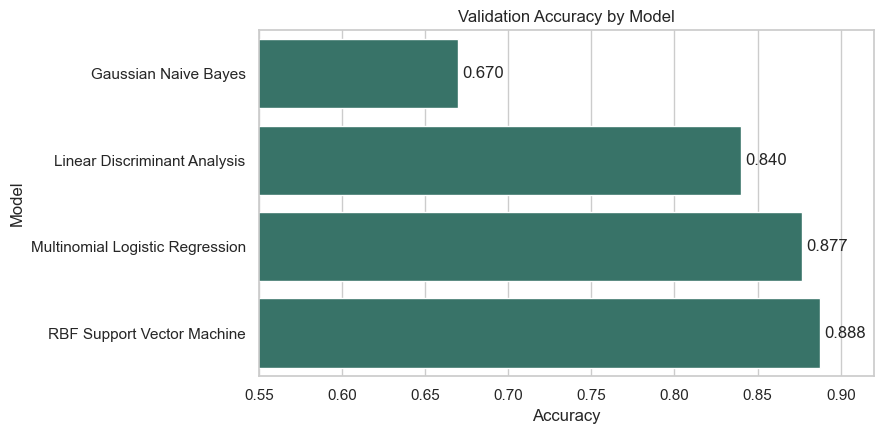

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = best_results.sort_values("Accuracy")
sns.barplot(data=plot_data, x="Accuracy", y="Model", color="#2E7D6E", ax=ax)
ax.set_xlim(0.55, 0.92)
ax.set_title("Validation Accuracy by Model")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

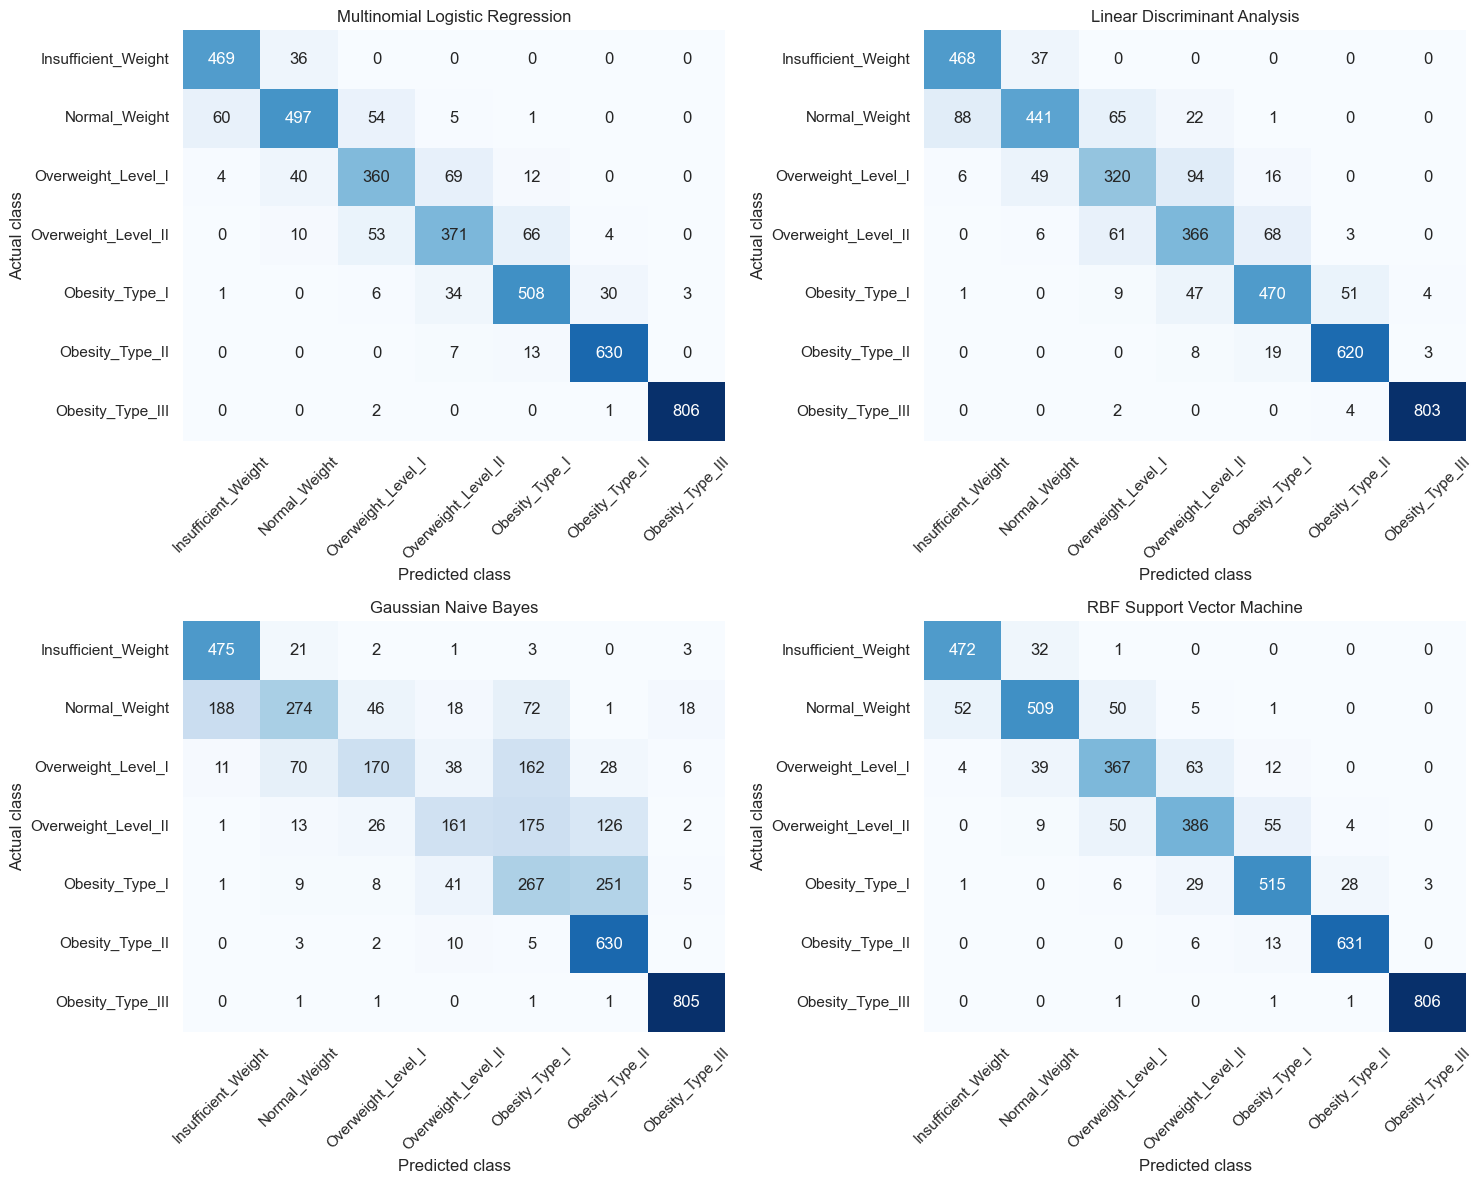


 Multinomial Logistic Regression
                     precision    recall  f1-score   support

Insufficient_Weight      0.878     0.929     0.903       505
      Normal_Weight      0.852     0.806     0.828       617
 Overweight_Level_I      0.758     0.742     0.750       485
Overweight_Level_II      0.763     0.736     0.749       504
     Obesity_Type_I      0.847     0.873     0.860       582
    Obesity_Type_II      0.947     0.969     0.958       650
   Obesity_Type_III      0.996     0.996     0.996       809

           accuracy                          0.877      4152
          macro avg      0.863     0.864     0.864      4152
       weighted avg      0.876     0.877     0.876      4152


 Linear Discriminant Analysis
                     precision    recall  f1-score   support

Insufficient_Weight      0.831     0.927     0.876       505
      Normal_Weight      0.827     0.715     0.767       617
 Overweight_Level_I      0.700     0.660     0.679       485
Overweight_Level

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for ax, (model_name, (_, pipeline, prediction, _)) in zip(axes.flat, selected.items()):
    cm = confusion_matrix(y_valid, prediction, labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
    ax.set_title(model_name)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

for model_name, (_, pipeline, prediction, _) in selected.items():
    print("\n", model_name)
    print(classification_report(y_valid, prediction, labels=CLASS_ORDER, digits=3))

### Error interpretation

The SVM recalls `Obesity_Type_III` at 99.6% and `Obesity_Type_II` at 97.1%, but recall falls to 75.7% for `Overweight_Level_I` and 76.6% for `Overweight_Level_II`.  Logistic regression shows a similar pattern.  The central categories share neighboring BMI ranges and overlapping behaviors, making them intrinsically harder to separate than the extreme categories.  Naïve Bayes has particularly low recall for `Overweight_Level_I` (35.1%) and `Overweight_Level_II` (31.9%), demonstrating that a respectable 67.0% aggregate accuracy conceals large class-specific deficiencies.

## 8. Model interpretation

In [10]:
# Multinomial coefficient interpretation
logit_pipeline = selected["Multinomial Logistic Regression"][1]
feature_names = logit_pipeline.named_steps["preprocess"].get_feature_names_out()
logit_model = logit_pipeline.named_steps["model"]
coefficient_frame = pd.DataFrame(
    logit_model.coef_, index=logit_model.classes_, columns=feature_names
)

for class_name in logit_model.classes_:
    row = coefficient_frame.loc[class_name]
    top = row.reindex(row.abs().sort_values(ascending=False).index).head(8)
    print(f"\nLargest coefficients for {class_name}")
    display(top.to_frame("Coefficient"))


Largest coefficients for Insufficient_Weight


,Coefficient
numeric__Weight,-13.933340
numeric__BMI,-11.537738
numeric__Age,-2.993677
categorical__Gender_Female,-2.577444
categorical__family_history_with_overweight_yes,-2.407979
categorical__CALC_Frequently,-2.394858
numeric__Age_sq,2.211113
categorical__SMOKE_yes,-2.172030



Largest coefficients for Normal_Weight


,Coefficient
numeric__BMI,-8.876087
numeric__Weight,-4.660621
categorical__MTRANS_Motorbike,1.635754
categorical__CAEC_Always,1.264563
numeric__Age,-1.086392
categorical__MTRANS_Public_Transportation,-1.029369
categorical__Gender_Male,1.021766
numeric__FCVC,-0.874402



Largest coefficients for Obesity_Type_I


...

,Coefficient
numeric__Weight,8.193170
numeric__BMI,7.315105
numeric__FCVC,6.186975
categorical__Gender_Male,-4.607133
categorical__MTRANS_Automobile,-3.735096
categorical__Gender_Female,2.543844
categorical__MTRANS_Public_Transportation,2.472452
categorical__CALC_no,-2.442400



Largest coefficients for Overweight_Level_I


,Coefficient
numeric__Weight,-8.540265
numeric__BMI,3.468740
numeric__Age,-2.243990
numeric__Age_sq,1.976821
numeric__Height,1.735544
categorical__SCC_yes,1.592773
categorical__family_history_with_overweight_no,1.520708
categorical__CAEC_no,1.462190



Largest coefficients for Overweight_Level_II


,Coefficient
numeric__Weight,5.310183
numeric__BMI,-3.028951
numeric__Height,-1.772151
categorical__FAVC_no,1.491249
categorical__Gender_Male,1.412957
categorical__CALC_Frequently,1.333118
numeric__Age_sq,1.306668
numeric__FCVC,-1.133169


In [11]:
# Model-agnostic permutation importance for the selected SVM
svm_pipeline = selected["RBF Support Vector Machine"][1]
svm_importance = permutation_importance(
    svm_pipeline, X_valid, y_valid, scoring="accuracy",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)
importance_table = pd.DataFrame({
    "Feature": X.columns,
    "Mean Accuracy Decrease": svm_importance.importances_mean,
    "SD": svm_importance.importances_std
}).sort_values("Mean Accuracy Decrease", ascending=False)
display(importance_table.head(12).round(4))

,Feature,Mean Accuracy Decrease,SD
16,BMI,0.4458,0.0018
3,Weight,0.4266,0.0037
0,Gender,0.1776,0.0031
6,FCVC,0.0790,0.0030
1,Age,0.0259,0.0013
2,Height,0.0208,0.0024
14,CALC,0.0138,0.0021
10,CH2O,0.0109,0.0018
5,FAVC,0.0105,0.0016
17,Age_sq,0.0099,0.0015


Permutation analysis shows that the SVM relies most heavily on `BMI` (mean accuracy decrease 0.446), `Weight` (0.427), `Gender` (0.178), and vegetable-consumption frequency `FCVC` (0.079).  Because correlated features can substitute for one another, these decreases should be interpreted as predictive dependence rather than causal effects.  In the multinomial model, large coefficients for `Weight` and `BMI` differentiate the higher obesity classes, while behavioral and transport indicators refine the boundaries.  For example, the `Obesity_Type_III` equation has strong positive standardized coefficients for `Weight`, `BMI`, and `FCVC`; coefficient signs are class-relative log-odds effects and must not be interpreted as causal health effects.

## 9. Refit all four selected models and create Kaggle submissions

In [12]:
OUTPUT_DIR = Path("obesity_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

submission_paths = {}
submission_filenames = {
    "Multinomial Logistic Regression": "submission_Multinomial_Logistic.csv",
    "Linear Discriminant Analysis": "submission_Linear_Discriminant_Analysis.csv",
    "Gaussian Naive Bayes": "submission_Gaussian_Naive_Bayes.csv",
    "RBF Support Vector Machine": "submission_RBF_Support_Vector_Machine.csv"
}
for model_name, (_, chosen_pipeline, _, _) in selected.items():
    final_pipeline = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", clone(chosen_pipeline.named_steps["model"]))
    ])
    final_pipeline.fit(X, y)
    kaggle_prediction = final_pipeline.predict(X_kaggle)

    output_path = OUTPUT_DIR / submission_filenames[model_name]
    submission = sample_submission.copy()
    submission[TARGET] = kaggle_prediction
    submission.to_csv(output_path, index=False)

    assert submission.shape == (13840, 2)
    assert submission.columns.tolist() == [ID, TARGET]
    assert submission[ID].equals(sample_submission[ID])
    assert submission[TARGET].notna().all()
    assert set(submission[TARGET]).issubset(set(y.unique()))
    submission_paths[model_name] = output_path

display(pd.DataFrame({"Model": submission_paths.keys(), "File": submission_paths.values()}))

,Model,File
0,Multinomial Logistic Regression,obesity_outputs\submission_Multinomial_Logisti...
1,Linear Discriminant Analysis,obesity_outputs\submission_Linear_Discriminant...
2,Gaussian Naive Bayes,obesity_outputs\submission_Gaussian_Naive_Baye...
3,RBF Support Vector Machine,obesity_outputs\submission_RBF_Support_Vector_...


## 10. Kaggle submission evidence

Four validated files are produced, one for each required model.  After upload, the Kaggle submissions page should be captured showing the filename, successful status, timestamp, and public accuracy score for each model.  Those records constitute the required evidence of successful submission.  Kaggle scores are not inserted in advance because they exist only after the competition accepts and evaluates each file.

| Required model | Submission file |
|---|---|
| Multinomial logistic regression | `submission_Multinomial_Logistic.csv` |
| Linear discriminant analysis | `submission_Linear_Discriminant_Analysis.csv` |
| Gaussian naïve Bayes | `submission_Gaussian_Naive_Bayes.csv` |
| RBF support vector machine | `submission_RBF_Support_Vector_Machine.csv` |

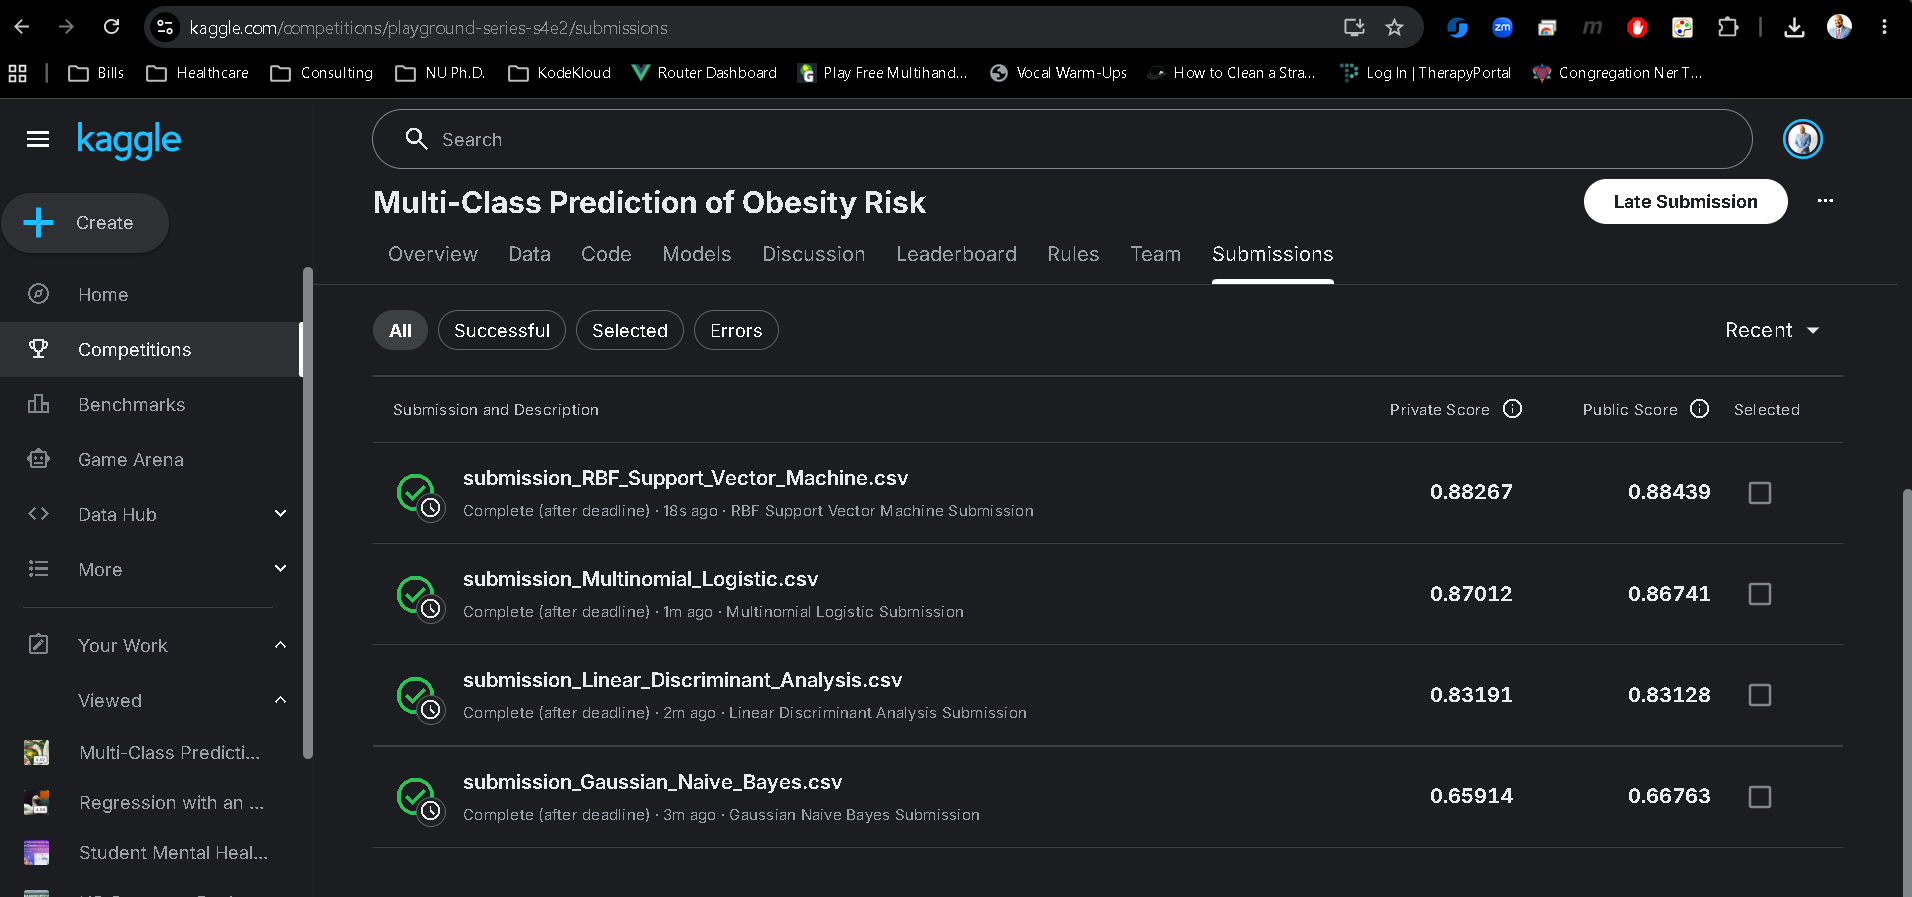

In [13]:
from IPython.display import Image, display

image_path = r"C:\Users\perez\OneDrive\National University\PhD\04_PredictiveAnalytics\Week05\KaggleSubmissionProof_Week5.png"  
display(Image(filename=image_path))

## 11. Findings and limitations

Among the four required classifiers, the RBF SVM produced the strongest observed generalization performance.  It achieved 88.78% accuracy on the untouched local validation set, followed by multinomial logistic regression at 87.69%, regularized LDA at 84.01%, and Gaussian naïve Bayes at 67.00%.  The SVM’s advantage over the linear models is consistent with the presence of nonlinear thresholds and interactions among anthropometric, behavioral, and demographic predictors.  However, the results do not prove that the underlying relationships possess a particular functional form; they show that the radial-kernel decision structure predicted this dataset more effectively than the alternative specifications tested.

The SVM’s performance was also consistent across the local validation and Kaggle evaluations.  Its Kaggle public score of 0.88439 and private score of 0.88267 were close to its local validation accuracy, suggesting that the fitted model generalized reliably across the synthetic competition partitions.  The small difference between the public and private scores also provides some evidence that the model was not narrowly adapted to the public leaderboard.  This conclusion applies to the competition environment and should not be extended automatically to independently collected health data.

Multinomial logistic regression remained highly competitive and provided the clearest framework for class-specific parameter interpretation.  Its comparatively strong results indicate that much of the separation among obesity categories can be represented through linear combinations of the transformed predictors.  Nevertheless, the coefficients require cautious interpretation because `BMI`, `Weight`, and `Height` are mathematically related, L2 regularization shrinks correlated estimates, and coefficient direction does not establish a causal effect.

Regularized LDA also performed reasonably despite clear departures from multivariate normality and equal class covariance.  Its results suggest that approximately linear discriminant boundaries retain useful predictive information, while covariance shrinkage helps stabilize the model in the presence of one-hot indicators and correlated anthropometric features.  Gaussian naïve Bayes produced the weakest results.  Its lower performance is consistent with—although not conclusively caused by—the substantial violations of conditional independence and class-conditional Gaussianity identified during the assumption investigation.  In particular, mathematically related anthropometric variables and associated behavioral characteristics may cause the model to count overlapping information more than once.

The confusion matrices and class-specific metrics provide additional context beyond overall accuracy.  Errors should be examined according to both their frequency and their location.  Misclassification between adjacent categories is substantively more plausible than confusion between the extreme categories because neighboring weight-status groups can have similar anthropometric and behavioral profiles.  Balanced accuracy and macro-\(F_1\) help determine whether strong overall accuracy conceals weaker performance for less-common classes, while the confusion matrices identify the specific categories the models have difficulty separating.

The analysis nevertheless has several limitations.  Hyperparameters were selected from a finite candidate grid through cross-validation conducted within the development partition.  Although the final validation set was not used for tuning, the selected models remain conditional on the preprocessing choices, engineered features, candidate algorithms, and hyperparameter ranges considered.  A broader search or different resampling design might produce a different final specification.  The validation estimates also reflect a single partition of data originating from the same synthetic generation process as the training observations.

The competition data introduce two related limitations to external validity.  First, most records in the original obesity dataset were created synthetically with SMOTE after a much smaller group of observations was collected through an online survey.  Second, Kaggle generated its competition data using a deep-learning model trained on that original dataset.  The competition observations may therefore reproduce regularities, dependencies, and artifacts from the source data more strongly than independently collected clinical observations would.  The regional origins of the original data—Colombia, Peru, and Mexico—also limit assumptions about generalization to other populations.

The construction of the outcome presents another important limitation.  The original obesity labels were derived primarily from body mass index, making `Weight`, `Height`, and engineered `BMI` unusually direct predictors of the target.  Their dominance is therefore expected and does not establish that they independently explain the broader behavioral or biological processes associated with obesity.  Similarly, permutation importance, regression coefficients, and other predictive importance measures describe contributions to classification within the fitted model; they do not demonstrate causal relationships.

Finally, the seven outcome categories are conceptually ordered, but Kaggle evaluates them as nominal classes.  The scoring procedure assigns the same penalty to an error between adjacent categories as it assigns to an error between extreme categories.  Accuracy is appropriate for comparison with the official competition results, but it does not measure the substantive severity of individual errors or the calibration of predicted risk.  These models should therefore be understood as educational predictive models developed for a structured competition—not as clinical diagnostic instruments or substitutes for professional health assessment.